<a href="https://colab.research.google.com/github/larissavaladao/time_series_curuai/blob/main/5.%20parameters_by_period/1.set_periods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# importar bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# importar dados

In [4]:
#dados obidos = cotas
#eliminar dados duplicados para o mesmo dia
obidos = pd.read_csv('/content/drive/MyDrive/CURUAI_PROCESS/17050001_Cotas.csv').drop_duplicates(subset=['Data'])
obidos = obidos[['EstacaoCodigo', 'Data',  'Maxima', 'Minima', 'Media' ]].copy()
obidos['Data'] = pd.to_datetime(obidos['Data'],dayfirst=True )
obidos

,EstacaoCodigo,Data,Maxima,Minima,Media
0,17050001,2024-10-01,-64.0,-128.0,-102.0
3,17050001,2024-04-01,628.0,510.0,570.0
6,17050001,2024-03-01,510.0,414.0,467.0
9,17050001,2024-02-01,412.0,320.0,370.0
12,17050001,2024-01-01,318.0,160.0,251.0
...,...,...,...,...,...
1940,17050001,1968-06-01,648.0,583.0,617.0
1942,17050001,1968-05-01,646.0,575.0,621.0
1944,17050001,1968-04-01,570.0,478.0,521.0
1946,17050001,1968-03-01,478.0,401.0,436.0


In [5]:
# dados curuai = cotas
#eliminar dados duplicados para o mesmo dia
curuai = pd.read_csv('/content/drive/MyDrive/CURUAI_PROCESS/17060000_Cotas.csv').drop_duplicates(subset=['Data'])
curuai = curuai[['EstacaoCodigo', 'Data',  'Maxima', 'Minima', 'Media' ]].copy()
curuai['Data'] = pd.to_datetime(curuai['Data'],dayfirst=True)
curuai

,EstacaoCodigo,Data,Maxima,Minima,Media
0,17060000,2019-03-01,NaN,NaN,NaN
4,17060000,2019-02-01,904.0,805.0,848.0
8,17060000,2019-01-01,805.0,683.0,747.0
12,17060000,2018-12-01,682.0,465.0,569.0
16,17060000,2018-11-01,461.0,418.0,431.0
...,...,...,...,...,...
1383,17060000,1983-01-01,693.0,597.0,649.0
1387,17060000,1982-12-01,590.0,489.0,540.0
1391,17060000,1982-11-01,NaN,NaN,NaN
1395,17060000,1982-10-01,NaN,NaN,NaN


In [6]:
# concatenar dados das duas estações e restringir para o periodo de tempo que há dados em curuai
cotas = pd.concat([obidos, curuai]).sort_values(by='Data').set_index('Data')
cotas = cotas.loc[curuai['Data'].min():curuai['Data'].max()]

In [7]:
# reajustar indices da tabela para gerar gráfico
cotas = cotas.reset_index()
cotas

,Data,EstacaoCodigo,Maxima,Minima,Media
0,1982-09-01,17050001,514.0,315.0,425.0
1,1982-09-01,17060000,789.0,609.0,711.0
2,1982-10-01,17060000,NaN,NaN,NaN
3,1982-10-01,17050001,308.0,142.0,217.0
4,1982-11-01,17050001,176.0,143.0,155.0
...,...,...,...,...,...
857,2019-01-01,17060000,805.0,683.0,747.0
858,2019-02-01,17050001,634.0,530.0,577.0
859,2019-02-01,17060000,904.0,805.0,848.0
860,2019-03-01,17060000,NaN,NaN,NaN


<Axes: xlabel='Data', ylabel='Media'>

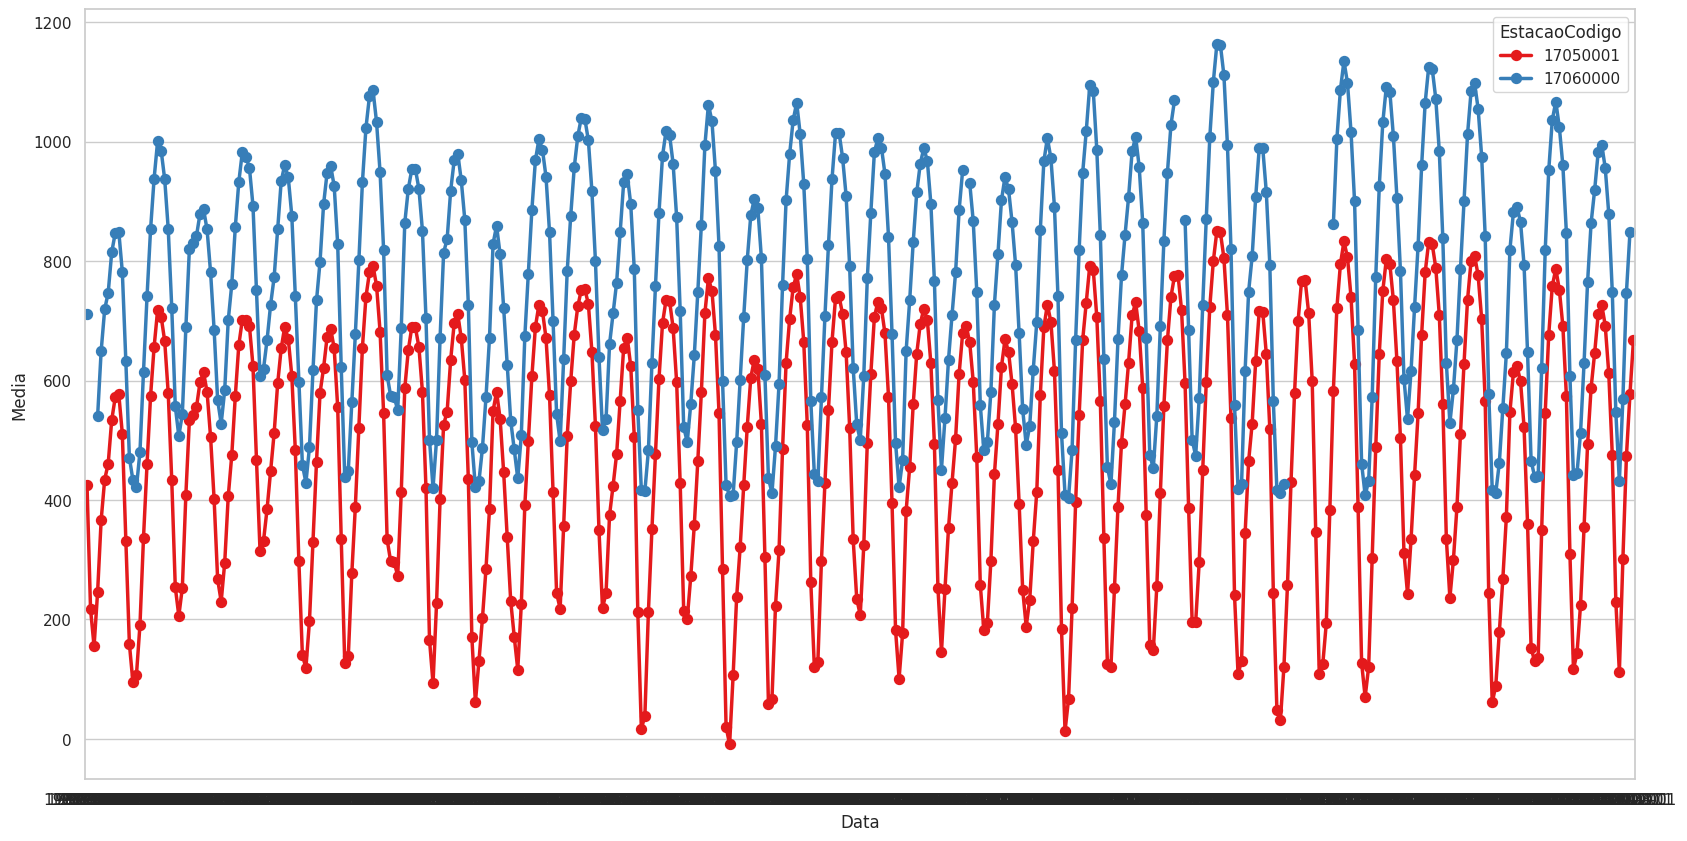

In [8]:
#comparar dados = seguem o mesmo padrão, aproximadamente
sns.set_theme(style="whitegrid",rc={'figure.figsize':(20,10)})
sns.pointplot(data=cotas,x = cotas['Data'],y = cotas['Media'], hue = cotas['EstacaoCodigo'], palette="Set1", linewidth=2.5)
# mostra que dados das duas estações tem comportamento similar, apesar dos valores de curuai serem maiores que o de obidos.

<Axes: xlabel='Data', ylabel='Media'>

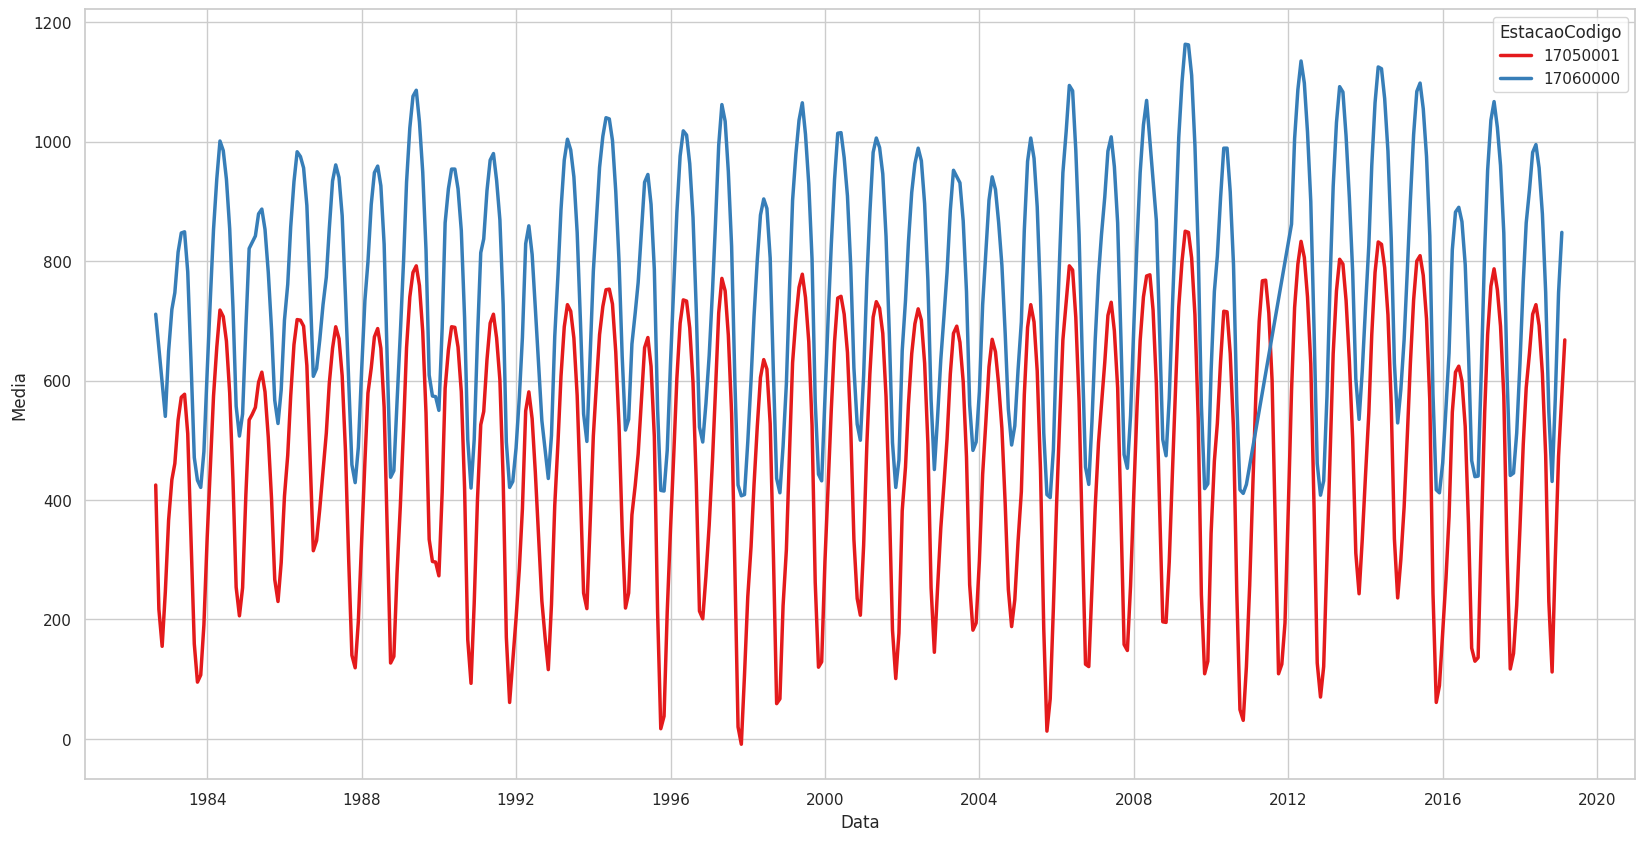

In [9]:
#comparar dados = seguem o mesmo padrão, aproximadamente
# grafico de linhas
sns.set_theme(style="whitegrid",rc={'figure.figsize':(20,10)})
sns.lineplot(data=cotas,x = cotas['Data'],y = cotas['Media'], hue = cotas['EstacaoCodigo'], palette="Set1", linewidth=2.5)

# Trabalhar com dados de Obidos

In [10]:
# adicionar periodos de água a partir de valores estabelecidos a partir do gráfico
def set_period(row):
  media = row['Media']
  data = row['Data']
  if media > 550:
    return 'HW'
  elif media < 350:
    return 'LW'
  elif media >= 350 and media <= 550:
    return "T"


In [11]:
# obter dados de óbidos apenas para o periodo entre 2000 e 2024
obidos_att = obidos.loc[(obidos['Data'].dt.year >= 1990) & (obidos['Data'].dt.year < 2025)].copy()
obidos_att = obidos_att.sort_values(by='Data').reset_index(drop=True)
obidos_att['water_period3'] = obidos_att.apply(lambda row: set_period(row),axis = 1)
obidos_att.describe()

,EstacaoCodigo,Data,Maxima,Minima,Media
count,413.0,413,413.000000,413.000000,413.000000
mean,17050001.0,2007-03-02 15:51:51.864406784,535.079903,428.934625,482.687651
min,17050001.0,1990-01-01 00:00:00,-64.000000,-128.000000,-102.000000
25%,17050001.0,1998-08-01 00:00:00,385.000000,210.000000,285.000000
50%,17050001.0,2007-03-01 00:00:00,585.000000,467.000000,528.000000
75%,17050001.0,2015-10-01 00:00:00,714.000000,645.000000,683.000000
max,17050001.0,2024-10-01 00:00:00,860.000000,839.000000,850.000000
std,0.0,NaN,214.003314,242.337681,229.531439


In [12]:
obidos_att['fall'] = ((obidos_att.loc[obidos_att['water_period3'] == "T"]['Data'].dt.month >= 1) & (obidos_att.loc[obidos_att['water_period3'] == "T"]['Data'].dt.month <= 4)) | (obidos_att.loc[obidos_att['water_period3'] == "T"]['Data'].dt.month == 12)
obidos_att['rise'] = ((obidos_att.loc[obidos_att['water_period3'] == "T"]['Data'].dt.month >= 6) & (obidos_att.loc[obidos_att['water_period3'] == "T"]['Data'].dt.month <= 10))

In [13]:
# adicionar periodos de água a partir de valores estabelecidos a partir do gráfico
def set_fall_rise(row):
  if row['rise'] == True and row['water_period3'] == 'T':
    return 'R'
  elif row['fall'] == True and row['water_period3'] == 'T':
    return 'F'
  else:
    return row['water_period3']

obidos_att['water_period'] = obidos_att.apply(lambda row: set_fall_rise(row),axis = 1)
obidos_att

,EstacaoCodigo,Data,Maxima,Minima,Media,water_period3,fall,rise,water_period
0,17050001,1990-01-01,315.0,256.0,273.0,LW,NaN,NaN,LW
1,17050001,1990-02-01,515.0,323.0,413.0,T,True,False,F
2,17050001,1990-03-01,631.0,520.0,587.0,HW,NaN,NaN,HW
3,17050001,1990-04-01,677.0,631.0,651.0,HW,NaN,NaN,HW
4,17050001,1990-05-01,698.0,679.0,690.0,HW,NaN,NaN,HW
...,...,...,...,...,...,...,...,...,...
408,17050001,2024-01-01,318.0,160.0,251.0,LW,NaN,NaN,LW
409,17050001,2024-02-01,412.0,320.0,370.0,T,True,False,F
410,17050001,2024-03-01,510.0,414.0,467.0,T,True,False,F
411,17050001,2024-04-01,628.0,510.0,570.0,HW,NaN,NaN,HW


In [14]:
obidos_att['HW'] = 550
obidos_att['LW'] = 350

<Axes: xlabel='Data', ylabel='Media'>

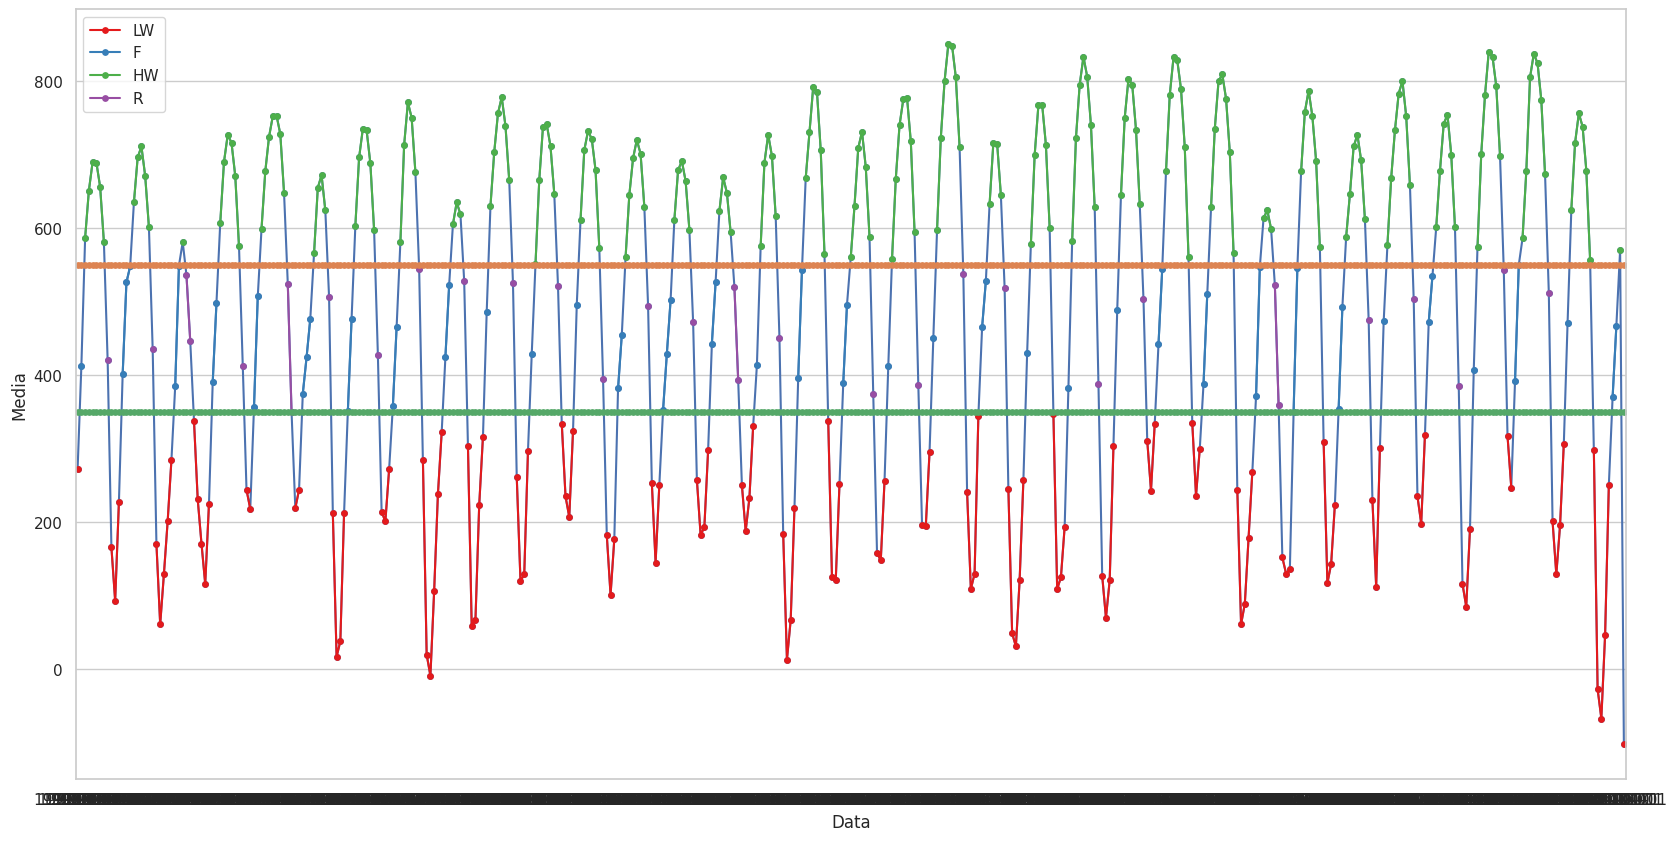

In [15]:
sns.set_theme(style="whitegrid",rc={'figure.figsize':(20,10)})
sns.pointplot(data=obidos_att,x = obidos_att['Data'],y = obidos_att['Media'],  linewidth=1.5)
sns.pointplot(data=obidos_att,x = obidos_att['Data'],y = obidos_att['Media'], hue = obidos_att['water_period'], palette="Set1", linewidth=1.5)
sns.pointplot(data=obidos_att,x = obidos_att['Data'],y = obidos_att['HW'],  linewidth=1.5)
sns.pointplot(data=obidos_att,x = obidos_att['Data'],y = obidos_att['LW'],  linewidth=1.5)

In [16]:
obidos_att['longitude'] = -55.5131
obidos_att['latitude'] = -1.9192

In [17]:
sub = obidos_att[0:14]
sub

,EstacaoCodigo,Data,Maxima,Minima,Media,water_period3,fall,rise,water_period,HW,LW,longitude,latitude
0,17050001,1990-01-01,315.0,256.0,273.0,LW,NaN,NaN,LW,550,350,-55.5131,-1.9192
1,17050001,1990-02-01,515.0,323.0,413.0,T,True,False,F,550,350,-55.5131,-1.9192
2,17050001,1990-03-01,631.0,520.0,587.0,HW,NaN,NaN,HW,550,350,-55.5131,-1.9192
3,17050001,1990-04-01,677.0,631.0,651.0,HW,NaN,NaN,HW,550,350,-55.5131,-1.9192
4,17050001,1990-05-01,698.0,679.0,690.0,HW,NaN,NaN,HW,550,350,-55.5131,-1.9192
5,17050001,1990-06-01,700.0,682.0,689.0,HW,NaN,NaN,HW,550,350,-55.5131,-1.9192
6,17050001,1990-07-01,682.0,631.0,656.0,HW,NaN,NaN,HW,550,350,-55.5131,-1.9192
7,17050001,1990-08-01,628.0,516.0,581.0,HW,NaN,NaN,HW,550,350,-55.5131,-1.9192
8,17050001,1990-09-01,511.0,298.0,420.0,T,False,True,R,550,350,-55.5131,-1.9192
9,17050001,1990-10-01,291.0,42.0,166.0,LW,NaN,NaN,LW,550,350,-55.5131,-1.9192


<Axes: xlabel='Data', ylabel='Media'>

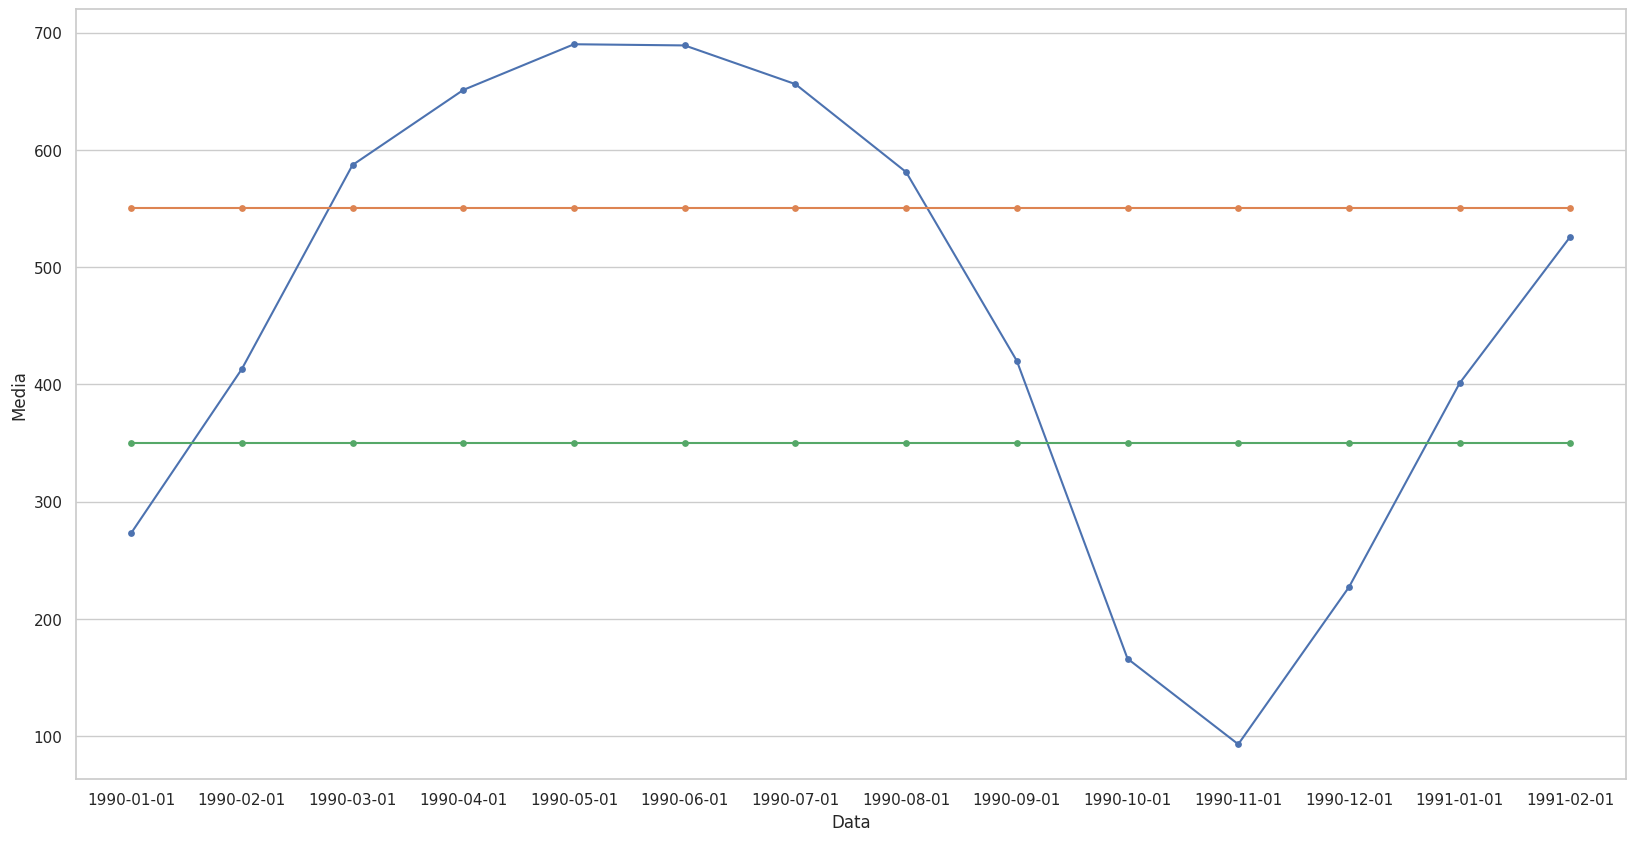

In [18]:
sns.pointplot(x = sub['Data'],y = sub['Media'],  linewidth=1.5)
sns.pointplot(x = sub['Data'],y = sub['HW'],  linewidth=1.5)
sns.pointplot(x = sub['Data'],y = sub['LW'],  linewidth=1.5)

In [19]:
obidos_att['Change'] =   pd.DatetimeIndex(obidos_att.Data).asi8

obidos_att


,EstacaoCodigo,Data,Maxima,Minima,Media,water_period3,fall,rise,water_period,HW,LW,longitude,latitude,Change
0,17050001,1990-01-01,315.0,256.0,273.0,LW,NaN,NaN,LW,550,350,-55.5131,-1.9192,631152000000000000
1,17050001,1990-02-01,515.0,323.0,413.0,T,True,False,F,550,350,-55.5131,-1.9192,633830400000000000
2,17050001,1990-03-01,631.0,520.0,587.0,HW,NaN,NaN,HW,550,350,-55.5131,-1.9192,636249600000000000
3,17050001,1990-04-01,677.0,631.0,651.0,HW,NaN,NaN,HW,550,350,-55.5131,-1.9192,638928000000000000
4,17050001,1990-05-01,698.0,679.0,690.0,HW,NaN,NaN,HW,550,350,-55.5131,-1.9192,641520000000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,17050001,2024-01-01,318.0,160.0,251.0,LW,NaN,NaN,LW,550,350,-55.5131,-1.9192,1704067200000000000
409,17050001,2024-02-01,412.0,320.0,370.0,T,True,False,F,550,350,-55.5131,-1.9192,1706745600000000000
410,17050001,2024-03-01,510.0,414.0,467.0,T,True,False,F,550,350,-55.5131,-1.9192,1709251200000000000
411,17050001,2024-04-01,628.0,510.0,570.0,HW,NaN,NaN,HW,550,350,-55.5131,-1.9192,1711929600000000000


In [20]:
from sklearn.linear_model import LinearRegression
ols = LinearRegression()

date350 = []
date550 = []

for i in range(0,len(obidos_att)-1):
  y = obidos_att['Change'][i:i+2].copy()
  X = np.array(obidos_att['Media'][i:i+2]).reshape(-1, 1).copy()
  ols_fit = ols.fit(X, y)

  date = (ols_fit.coef_ * 350) + ols_fit.intercept_
  date2 = (ols_fit.coef_ * 550) + ols_fit.intercept_


  if ((float(date[0]) >= float(obidos_att['Change'][i])) & (float(date[0]) <= float(obidos_att['Change'][i+1]))):
    date350.append(float(date[0]))
    # print(float(date[0]))
  else:
    date350.append(999999)

  if (float(date2[0]) >= float(obidos_att['Change'][i])) & (float(date2[0]) <= float(obidos_att['Change'][i+1])):
    date550.append(float(date2[0]))
  else:
    date550.append(999999)


In [21]:
dfLw = pd.DataFrame({
    'LW_limit': date350})
dfLw = dfLw.loc[dfLw.LW_limit != 999999].copy().drop_duplicates()

dfLw['LW_limit'] = pd.to_datetime(dfLw['LW_limit'])
dfLw = dfLw.reset_index(drop=True)
dfLw['lim'] = 350

dfLw['longitude'] = -55.5131
dfLw['latitude'] = -1.9192

dfLw

,LW_limit,lim,longitude,latitude
0,1990-01-18 01:12:00.000000000,350,-55.5131,-1.9192
1,1990-09-09 06:25:30.708661376,350,-55.5131,-1.9192
2,1990-12-22 21:55:51.724137856,350,-55.5131,-1.9192
3,1991-09-10 14:56:36.226415104,350,-55.5131,-1.9192
4,1992-02-19 20:24:00.000000000,350,-55.5131,-1.9192
...,...,...,...,...
65,2022-09-16 15:02:53.633440512,350,-55.5131,-1.9192
66,2023-01-09 03:04:23.414634240,350,-55.5131,-1.9192
67,2023-08-25 18:37:31.737451520,350,-55.5131,-1.9192
68,2024-01-26 18:57:28.739495680,350,-55.5131,-1.9192


In [22]:
dfHw = pd.DataFrame({
    'HW_limit': date550})
dfHw = dfHw.loc[dfHw.HW_limit != 999999].copy().drop_duplicates()

dfHw['HW_limit'] = pd.to_datetime(dfHw['HW_limit'])
dfHw = dfHw.reset_index(drop=True)
dfHw['lim'] = 550

dfHw['longitude'] = -55.5131
dfHw['latitude'] = -1.9192

dfHw

,HW_limit,lim,longitude,latitude
0,1990-02-23 01:06:12.413793152,550,-55.5131,-1.9192
1,1990-08-06 23:15:16.770186368,550,-55.5131,-1.9192
2,1991-03-01 17:06:12.413793152,550,-55.5131,-1.9192
3,1991-08-10 12:34:41.927710848,550,-55.5131,-1.9192
4,1992-04-01 22:30:00.000000000,550,-55.5131,-1.9192
...,...,...,...,...
65,2022-08-24 16:23:51.055900672,550,-55.5131,-1.9192
66,2023-02-15 08:43:38.181818112,550,-55.5131,-1.9192
67,2023-08-01 20:06:29.189189120,550,-55.5131,-1.9192
68,2024-03-25 23:32:02.330097152,550,-55.5131,-1.9192


In [23]:
list_total = [dfLw['LW_limit'][0]]
list_lim = [dfLw['lim'][0]]
for i in range(0,len(dfHw)-1,2):

  list_total.append(dfHw['HW_limit'][i])
  list_total.append(dfHw['HW_limit'][i+1])
  print('i',i)
  print('i+1',i+1)

  list_lim.append(dfHw['lim'][i])
  list_lim.append(dfHw['lim'][i+1])

  list_total.append(dfLw['LW_limit'][i+1])
  list_lim.append(dfLw['lim'][i])
  if i+2 < 50:
    list_total.append(dfLw['LW_limit'][i+2])
    list_lim.append(dfLw['lim'][i+1])
    print('i+2',i+2)
  print()




print(len(list_total))

i 0
i+1 1
i+2 2

i 2
i+1 3
i+2 4

i 4
i+1 5
i+2 6

i 6
i+1 7
i+2 8

i 8
i+1 9
i+2 10

i 10
i+1 11
i+2 12

i 12
i+1 13
i+2 14

i 14
i+1 15
i+2 16

i 16
i+1 17
i+2 18

i 18
i+1 19
i+2 20

i 20
i+1 21
i+2 22

i 22
i+1 23
i+2 24

i 24
i+1 25
i+2 26

i 26
i+1 27
i+2 28

i 28
i+1 29
i+2 30

i 30
i+1 31
i+2 32

i 32
i+1 33
i+2 34

i 34
i+1 35
i+2 36

i 36
i+1 37
i+2 38

i 38
i+1 39
i+2 40

i 40
i+1 41
i+2 42

i 42
i+1 43
i+2 44

i 44
i+1 45
i+2 46

i 46
i+1 47
i+2 48

i 48
i+1 49

i 50
i+1 51

i 52
i+1 53

i 54
i+1 55

i 56
i+1 57

i 58
i+1 59

i 60
i+1 61

i 62
i+1 63

i 64
i+1 65

i 66
i+1 67

i 68
i+1 69

130


In [24]:
df = pd.DataFrame({
    'Data': list_total,
    'lim': list_lim
})


In [25]:
df

,Data,lim
0,1990-01-18 01:12:00.000000000,350
1,1990-02-23 01:06:12.413793152,550
2,1990-08-06 23:15:16.770186368,550
3,1990-09-09 06:25:30.708661376,350
4,1990-12-22 21:55:51.724137856,350
...,...,...
125,2023-08-01 20:06:29.189189120,550
126,2023-08-25 18:37:31.737451520,350
127,2024-03-25 23:32:02.330097152,550
128,2024-04-06 10:42:51.428571648,550


In [26]:
df['next'] = df['lim'].shift(-1)
df['previous'] = df['lim'].shift(+1)



In [27]:
def set_transition(row):
  if row['lim'] == 350 and row['next'] == 550:
    return'LW_to_R'
  elif row['lim'] == 550 and row['next'] == 550:
    return'R_to_HW'
  elif row['lim'] == 550 and row['next'] == 350:
    return'HW_to_F'
  elif row['lim'] == 350 and row['next'] == 350:
    return'F_to_LW'
  elif row['lim'] == 350 and row['previous'] == 550:
    return 'F_to_L'
df['type'] = df.apply(lambda row: set_transition(row),axis=1)
df

,Data,lim,next,previous,type
0,1990-01-18 01:12:00.000000000,350,550.0,NaN,LW_to_R
1,1990-02-23 01:06:12.413793152,550,550.0,350.0,R_to_HW
2,1990-08-06 23:15:16.770186368,550,350.0,550.0,HW_to_F
3,1990-09-09 06:25:30.708661376,350,350.0,550.0,F_to_LW
4,1990-12-22 21:55:51.724137856,350,550.0,350.0,LW_to_R
...,...,...,...,...,...
125,2023-08-01 20:06:29.189189120,550,350.0,550.0,HW_to_F
126,2023-08-25 18:37:31.737451520,350,550.0,550.0,LW_to_R
127,2024-03-25 23:32:02.330097152,550,550.0,350.0,R_to_HW
128,2024-04-06 10:42:51.428571648,550,350.0,550.0,HW_to_F


In [28]:
df = df[['Data','type']].copy()
df['day'] = df['Data'].dt.day
df['month'] = df['Data'].dt.month
df['year'] = df['Data'].dt.year

df['longitude'] = -55.5131
df['latitude'] = -1.9192

In [29]:
obidos_att.to_csv('/content/drive/MyDrive/CURUAI_PROCESS/vazao_obidos.csv')

In [30]:
df.to_csv('/content/drive/MyDrive/CURUAI_PROCESS/water_period_limits.csv')